# Reproducción de «Transition to superdiffusive transport in turbulent plasmas»

Este notebook reproduce, hasta donde permite una ejecución interactiva, los resultados centrales de Stanzani et al., Physical Review E 110, 025204 (2024), DOI: 10.1103/PhysRevE.110.025204. El PDF usado como referencia está en article/article.pdf.

Se implementan directamente las ecuaciones y el Apéndice A: potencial turbulento con M=25, giro-promedio J₀, corrección de segundo orden que introduce η, secciones de Poincaré, desplazamiento cuadrático medio (MSD), promedios de Birkhoff ponderados, mapa del exponente de transporte y reconstrucción de centros guía desde órbitas completas.

La reproducción no es pixel a pixel: el artículo no publica todos los detalles de selección y clasificación de trayectorias ni todos los puntos de su barrido. Además, su cálculo usa una malla 4096×4096, paso 0.005 y varios miles de periodos. Aquí se ofrece un perfil rápido reproducible y parámetros ARTICLE para una ejecución de alta fidelidad.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy.special import jv

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

TAU = 2 * np.pi
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.2})

## Perfiles numéricos

QUICK conserva la física y permite explorar el notebook. ARTICLE recoge las recomendaciones del Apéndice B; puede requerir muchas horas y bastante memoria. Los resultados cuantitativos de transporte son sensibles al tiempo total, al número de condiciones iniciales y a la resolución.

Las secciones largas están desactivadas por defecto. Activa RUN_SCAN y RUN_FULL_ORBITS cuando quieras ejecutar las reproducciones de las Figuras 7 y 9.

In [2]:
PROFILES = {
    'QUICK': dict(grid=256, dt_gc=0.05, periods=300, ntraj=24**2,
                  rotation_periods=1200, rotation_points=180),
    'ARTICLE': dict(grid=4096, dt_gc=0.005, periods=4500, ntraj=4096,
                    rotation_periods=10000, rotation_points=1000),
}

PROFILE = 'QUICK'
P = PROFILES[PROFILE]
A = 0.7
M = 25
SEED = 27
RUN_SCAN = False
RUN_FULL_ORBITS = False
P

{'grid': 256,
 'dt_gc': 0.05,
 'periods': 300,
 'ntraj': 576,
 'rotation_periods': 1200,
 'rotation_points': 180}

## Modelo y potencial efectivo

El potencial electrostático es φ(x,y,t)=Im[φc(x,y)e⁻ⁱᵗ], con coeficientes Knm=A exp(iϕnm)/(n²+m²)³ᐟ² para n,m≥1 y n²+m²≤M². Las fases siguen una distribución uniforme y se fijan con la semilla 27 usada por el código de referencia del repositorio.

El potencial de centros guía de segundo orden es

ψ = Im[J₀[φc]e⁻ⁱᵗ + η φ₂⁽⁰⁾ − η φ₂⁽²⁾e⁻²ⁱᵗ],

con φ₂⁽⁰⁾ y φ₂⁽²⁾ definidos en el Apéndice A. Esta corrección es imprescindible: a primer orden η no aparece en la dinámica de centros guía.

In [3]:
@dataclass
class EffectivePotential:
    ngrid: int
    rho: float
    eta: float
    phi_c: np.ndarray
    phi_c_dx: np.ndarray
    phi_c_dy: np.ndarray
    components: tuple[np.ndarray, np.ndarray, np.ndarray]
    dx_components: tuple[np.ndarray, np.ndarray, np.ndarray]
    dy_components: tuple[np.ndarray, np.ndarray, np.ndarray]

    @property
    def harmonics(self):
        return (1, 0, 2)

    def _evaluate_components(self, arrays, x, y, t):
        phases = (np.exp(-1j * harmonic * t) for harmonic in self.harmonics)
        return np.imag(sum(periodic_bilinear(field, x, y) * phase
                           for field, phase in zip(arrays, phases)))

    def value(self, x, y, t=0.0):
        return self._evaluate_components(self.components, x, y, t)

    def gradient(self, x, y, t=0.0):
        return (self._evaluate_components(self.dx_components, x, y, t),
                self._evaluate_components(self.dy_components, x, y, t))


def periodic_bilinear(field, x, y):
    n = field.shape[0]
    ux = np.mod(x, TAU) * n / TAU
    uy = np.mod(y, TAU) * n / TAU
    i0 = np.floor(ux).astype(np.int64) % n
    j0 = np.floor(uy).astype(np.int64) % n
    i1, j1 = (i0 + 1) % n, (j0 + 1) % n
    ax, ay = ux - np.floor(ux), uy - np.floor(uy)
    return ((1 - ax) * (1 - ay) * field[i0, j0]
            + ax * (1 - ay) * field[i1, j0]
            + (1 - ax) * ay * field[i0, j1]
            + ax * ay * field[i1, j1])


def fourier_wavenumbers(n):
    k = np.fft.fftfreq(n, d=1 / n)
    return np.meshgrid(k, k, indexing='ij')


def spectral_derivative(field, axis):
    kx, ky = fourier_wavenumbers(field.shape[0])
    wave = kx if axis == 0 else ky
    return np.fft.ifft2(1j * wave * np.fft.fft2(field))


def gyro_operator(field, rho, order):
    kx, ky = fourier_wavenumbers(field.shape[0])
    kmag = np.hypot(kx, ky)
    if order == 0:
        multiplier = jv(0, rho * kmag)
    elif order == 1:
        multiplier = (-0.5 * kmag**2 if np.isclose(rho, 0)
                      else -kmag * jv(1, rho * kmag) / rho)
    else:
        raise ValueError('order debe ser 0 o 1')
    return np.fft.ifft2(np.fft.fft2(field) * multiplier)


def turbulent_complex_field(ngrid, amplitude=A, modes=M, seed=SEED):
    phases = TAU * np.random.RandomState(seed).random((modes, modes))
    coefficients = np.zeros((ngrid, ngrid), dtype=np.complex128)
    for n in range(1, modes + 1):
        for m in range(1, modes + 1):
            if n*n + m*m <= modes*modes:
                coefficients[n, m] = (amplitude * np.exp(1j * phases[n-1, m-1])
                                        / (n*n + m*m)**1.5)
    return np.fft.ifft2(coefficients) * ngrid**2


def build_effective_potential(rho, eta, ngrid=P['grid']):
    phi_c = turbulent_complex_field(ngrid)
    j0_phi = gyro_operator(phi_c, rho, 0)
    phi20 = j0_phi * gyro_operator(np.conj(phi_c), rho, 1) \
            - 0.5 * gyro_operator(np.abs(phi_c)**2, rho, 1)
    phi22 = j0_phi * gyro_operator(phi_c, rho, 1) \
            - 0.5 * gyro_operator(phi_c**2, rho, 1)
    components = (j0_phi, eta * phi20, -eta * phi22)
    dx = tuple(spectral_derivative(field, 0) for field in components)
    dy = tuple(spectral_derivative(field, 1) for field in components)
    return EffectivePotential(ngrid, rho, eta, phi_c,
                              spectral_derivative(phi_c, 0), spectral_derivative(phi_c, 1),
                              components, dx, dy)


def original_potential_gradient(model, x, y, t):
    phase = np.exp(-1j * t)
    return (np.imag(periodic_bilinear(model.phi_c_dx, x, y) * phase),
            np.imag(periodic_bilinear(model.phi_c_dy, x, y) * phase))

## Figura 1: potencial original y potencial efectivo

Parámetros publicados: A=0.7, ρ=0.3 y η=0.14, en t=0.

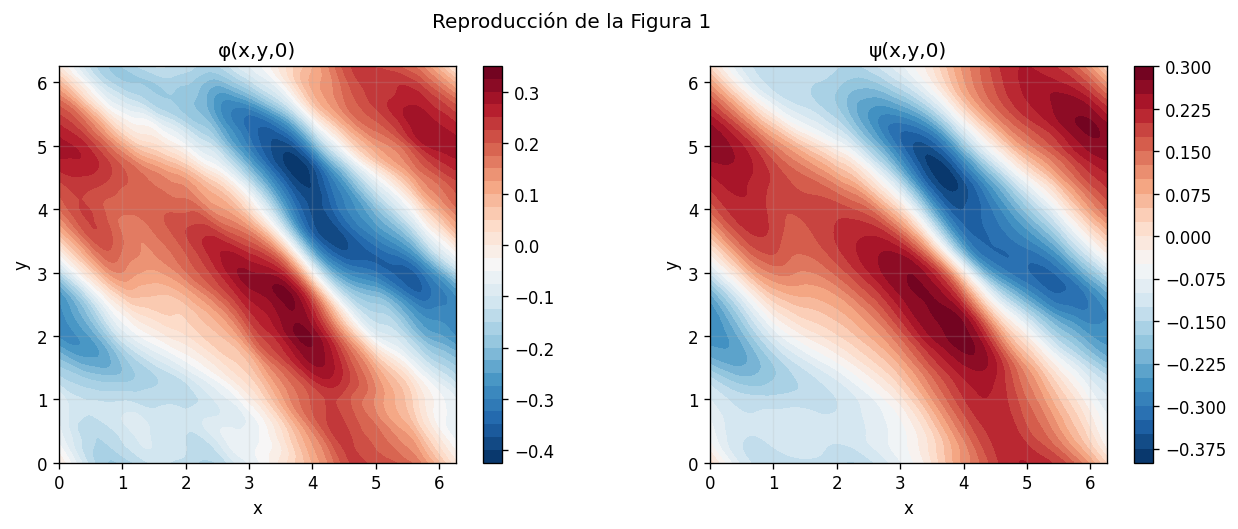

In [4]:
model_03 = build_effective_potential(rho=0.3, eta=0.14)
grid = np.linspace(0, TAU, model_03.ngrid, endpoint=False)
X, Y = np.meshgrid(grid, grid, indexing='ij')
phi_t0 = np.imag(model_03.phi_c)
psi_t0 = model_03.value(X, Y, 0.0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), constrained_layout=True)
for ax, field, title in zip(axes, (phi_t0, psi_t0), ('φ(x,y,0)', 'ψ(x,y,0)')):
    contour = ax.contourf(grid, grid, field.T, levels=30, cmap='RdBu_r')
    fig.colorbar(contour, ax=ax)
    ax.set(xlabel='x', ylabel='y', title=title, aspect='equal')
fig.suptitle('Reproducción de la Figura 1')
plt.show()

## Integrador y observables

Los centros guía obedecen Ẋ=−∂ψ/∂Y, Ẏ=∂ψ/∂X. Se integra con RK4 explícito y se guarda una muestra cada periodo 2π, igual que en el artículo. Las coordenadas se mantienen sin envolver para medir transporte; solo se aplica módulo 2π al dibujar la sección compacta.

El MSD implementa el promedio temporal y de conjunto de la ecuación publicada, evaluado sobre retardos logarítmicos para reducir coste.

In [5]:
def rhs_guiding_center(t, state, model):
    dpsi_dx, dpsi_dy = model.gradient(state[0], state[1], t)
    return np.stack((-dpsi_dy, dpsi_dx))


def rk4_stroboscopic(rhs, state0, periods, dt, args=()):
    steps_per_period = max(1, int(np.ceil(TAU / dt)))
    h = TAU / steps_per_period
    state = np.asarray(state0, dtype=float).copy()
    history = np.empty((periods + 1,) + state.shape, dtype=float)
    history[0] = state
    t = 0.0
    for period in range(1, periods + 1):
        for _ in range(steps_per_period):
            k1 = rhs(t, state, *args)
            k2 = rhs(t + h/2, state + h*k1/2, *args)
            k3 = rhs(t + h/2, state + h*k2/2, *args)
            k4 = rhs(t + h, state + h*k3, *args)
            state += h * (k1 + 2*k2 + 2*k3 + k4) / 6
            t += h
        history[period] = state
    return history, h


def fixed_initial_conditions(ntraj):
    side = int(np.sqrt(ntraj))
    values = np.linspace(0, TAU, side, endpoint=False)
    x0, y0 = np.meshgrid(values, values, indexing='ij')
    return np.stack((x0.ravel(), y0.ravel()))


def mobile_mask(positions, threshold=4.0):
    excursion = np.max(np.linalg.norm(positions - positions[:1], axis=1), axis=0)
    return excursion > threshold


def time_ensemble_msd(positions, mask=None, n_lags=70):
    if mask is None or not np.any(mask):
        mask = np.ones(positions.shape[-1], dtype=bool)
    max_lag = positions.shape[0] - 1
    lags = np.unique(np.geomspace(1, max_lag, min(n_lags, max_lag)).astype(int))
    values = []
    for lag in lags:
        delta = positions[lag:, :, mask] - positions[:-lag, :, mask]
        values.append(np.mean(np.sum(delta**2, axis=1)))
    return TAU * lags, np.asarray(values)


def fit_transport_exponent(times, msd, tail_fraction=0.6):
    valid = (times > 0) & (msd > 0) & np.isfinite(msd)
    x, y = np.log(times[valid]), np.log(msd[valid])
    start = max(0, int((1 - tail_fraction) * len(x)))
    slope, intercept = np.polyfit(x[start:], y[start:], 1)
    return slope, np.exp(intercept / slope) if slope != 0 else np.nan


def classify_trajectories(positions, trapped_threshold=4.0, ballistic_speed=0.02):
    excursion = np.max(np.linalg.norm(positions - positions[:1], axis=1), axis=0)
    speed = np.linalg.norm(positions[-1] - positions[0], axis=0) / (TAU * (len(positions)-1))
    trapped = excursion <= trapped_threshold
    ballistic = (~trapped) & (speed >= ballistic_speed)
    chaotic = ~(trapped | ballistic)
    return trapped, chaotic, ballistic


COLORS = {'trapped': '#31688e', 'chaotic': '#fdae61', 'ballistic': '#b35806'}

## Figuras 2 y 3: transición de difusión a transporte casi balístico

Se comparan (ρ,η)=(0,0) y (0.3,0.14), siempre con A=0.7 y M=25. La clasificación por color usa excursión y velocidad media como aproximación reproducible a la clasificación no completamente especificada en el texto.

In [6]:
initial = fixed_initial_conditions(P['ntraj'])
core_cases = {}
for label, (rho, eta) in {'Figura 2': (0.0, 0.0), 'Figura 3': (0.3, 0.14)}.items():
    started = time.perf_counter()
    model = build_effective_potential(rho, eta)
    positions, actual_dt = rk4_stroboscopic(
        rhs_guiding_center, initial, P['periods'], P['dt_gc'], args=(model,))
    mask = mobile_mask(positions)
    times, msd = time_ensemble_msd(positions, mask)
    exponent, scale = fit_transport_exponent(times, msd)
    core_cases[label] = dict(model=model, positions=positions, times=times,
                                  msd=msd, exponent=exponent, scale=scale)
    print(f'{label}: ρ={rho}, η={eta}, b={exponent:.3f}, dt={actual_dt:.5f}, '
          f'móviles={mask.sum()}/{mask.size}, tiempo={time.perf_counter()-started:.1f}s')

Figura 2: ρ=0.0, η=0.0, b=0.825, dt=0.04987, móviles=355/576, tiempo=80.7s
Figura 3: ρ=0.3, η=0.14, b=1.546, dt=0.04987, móviles=292/576, tiempo=69.4s


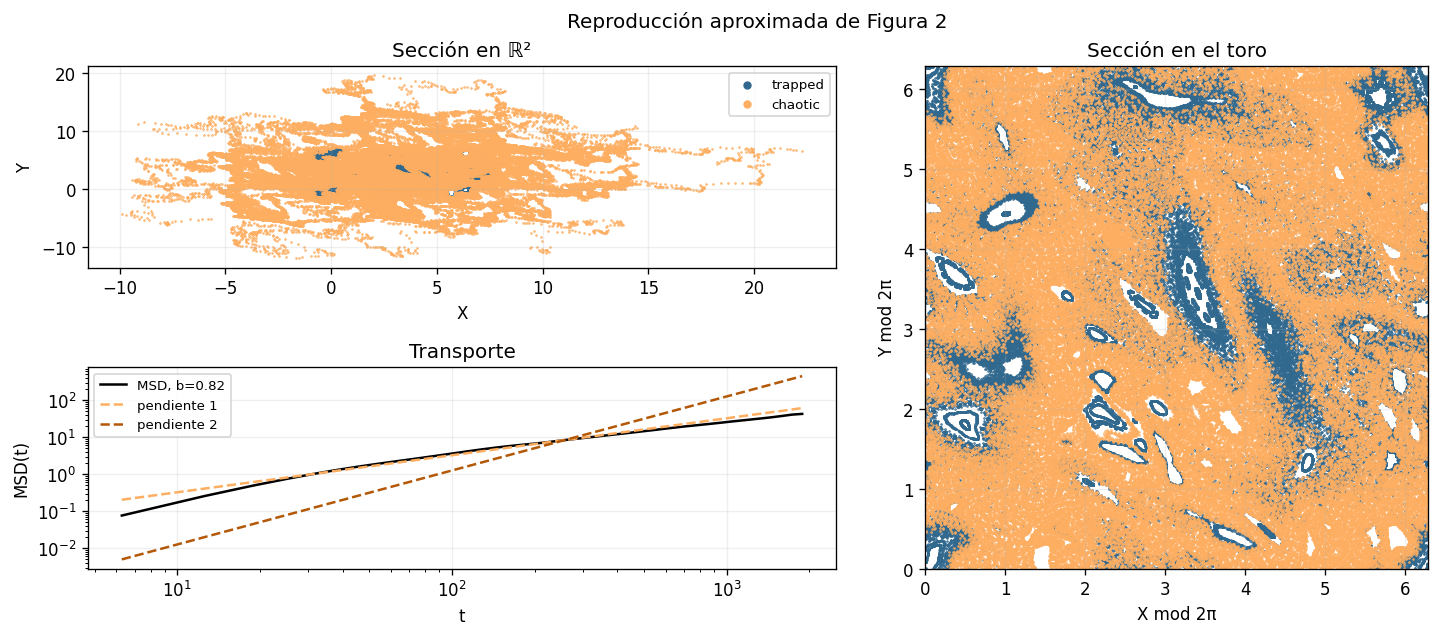

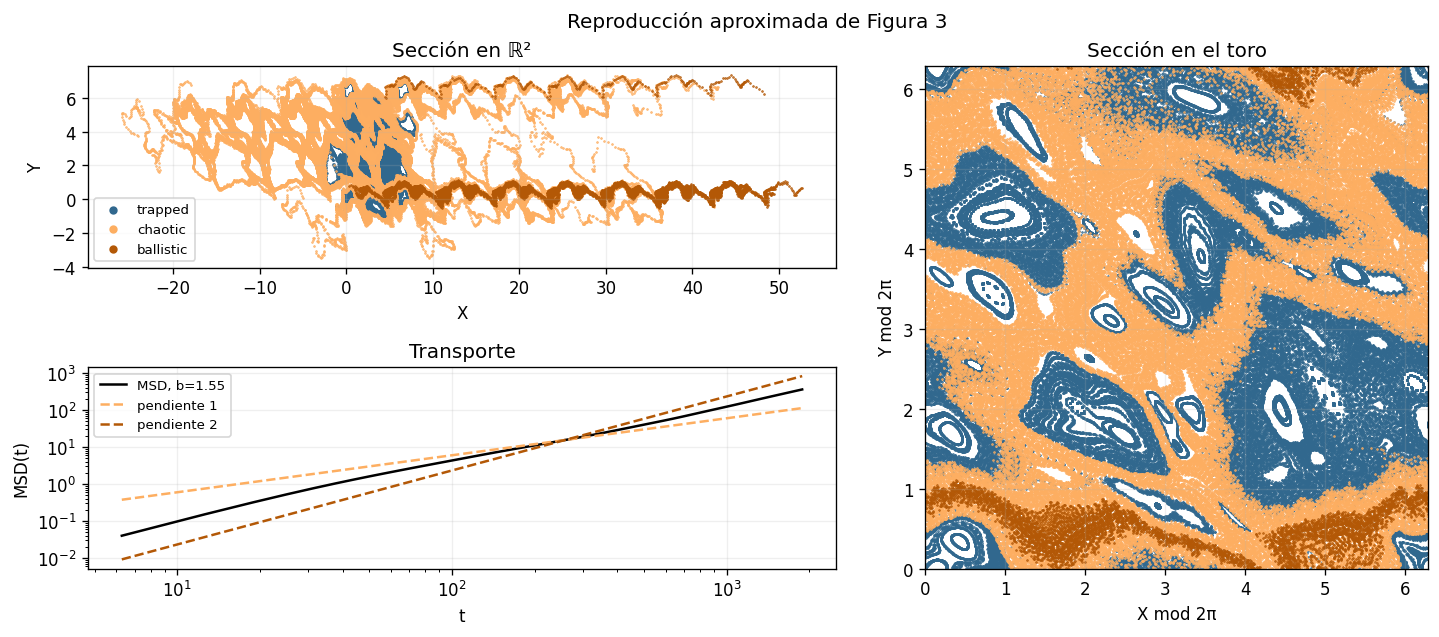

In [7]:
def plot_transport_triptych(case, title):
    positions, times, msd = case['positions'], case['times'], case['msd']
    trapped, chaotic, ballistic = classify_trajectories(positions)
    fig = plt.figure(figsize=(12.5, 5.2), constrained_layout=True)
    grid_spec = fig.add_gridspec(2, 2, width_ratios=(1.15, 1))
    ax_real = fig.add_subplot(grid_spec[0, 0])
    ax_msd = fig.add_subplot(grid_spec[1, 0])
    ax_mod = fig.add_subplot(grid_spec[:, 1])
    classes = ((trapped, 'trapped'), (chaotic, 'chaotic'), (ballistic, 'ballistic'))
    for mask, name in classes:
        if np.any(mask):
            ax_real.scatter(positions[:, 0, mask], positions[:, 1, mask], s=0.25,
                            color=COLORS[name], rasterized=True, label=name)
            ax_mod.scatter(np.mod(positions[:, 0, mask], TAU),
                           np.mod(positions[:, 1, mask], TAU), s=0.25,
                           color=COLORS[name], rasterized=True)
    ax_real.set(xlabel='X', ylabel='Y', title='Sección en ℝ²')
    ax_real.legend(markerscale=8, fontsize=8)
    ax_mod.set(xlabel='X mod 2π', ylabel='Y mod 2π', title='Sección en el toro',
               xlim=(0, TAU), ylim=(0, TAU), aspect='equal')
    ax_msd.loglog(times, msd, color='black', lw=1.5,
                  label=f'MSD, b={case["exponent"]:.2f}')
    anchor_t, anchor_y = times[len(times)//2], msd[len(msd)//2]
    ax_msd.loglog(times, anchor_y*(times/anchor_t), '--', color='#fdae61', label='pendiente 1')
    ax_msd.loglog(times, anchor_y*(times/anchor_t)**2, '--', color='#b35806', label='pendiente 2')
    ax_msd.set(xlabel='t', ylabel='MSD(t)', title='Transporte')
    ax_msd.legend(fontsize=8)
    fig.suptitle(title)
    return fig


for label, case in core_cases.items():
    _ = plot_transport_triptych(case, f'Reproducción aproximada de {label}')
    plt.show()

## Figuras 4 y 5: toro twistless y números de rotación

Para X₀=π se calcula r(Y₀) con el promedio de Birkhoff ponderado del artículo. Un extremo local de la curva indica pérdida de twist. El artículo cita Y₀*=0.58 y r≈0.087647 para ρ=0.3; para ρ=0.5 cita extremos en Y₀*=0.7552 y Y₀**=1.41423.

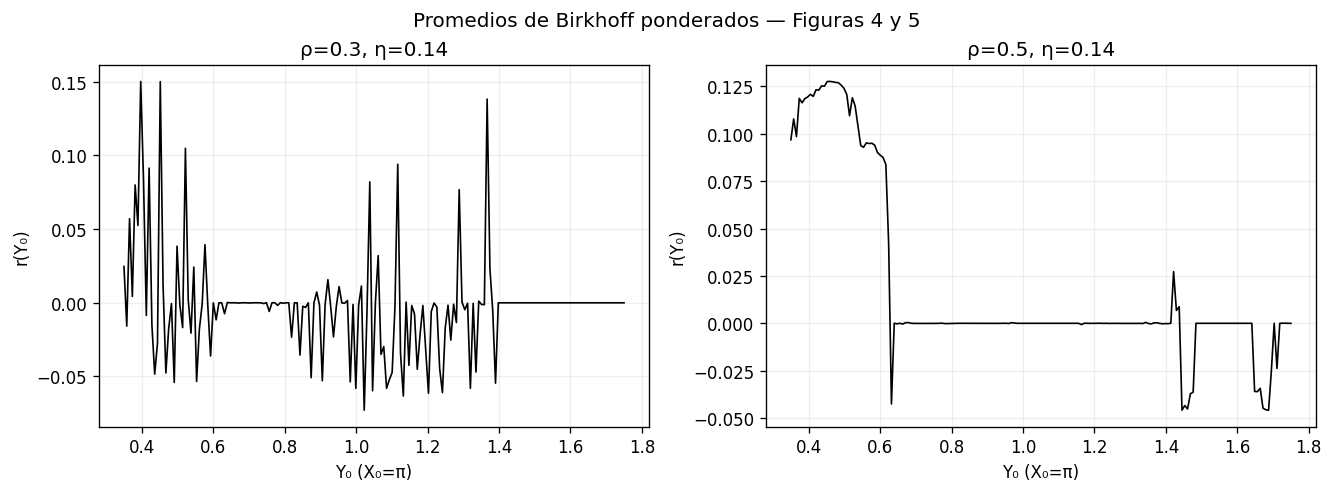

In [8]:
def bump_weights(size):
    s = np.arange(1, size + 1) / (size + 1)
    weights = np.exp(-1 / (s * (1 - s)))
    return weights / weights.sum()


def weighted_rotation_numbers(positions):
    increments = np.diff(positions[:, 0, :], axis=0)
    return np.sum(increments * bump_weights(len(increments))[:, None], axis=0)


rotation_results = {}
y0 = np.linspace(0.35, 1.75, P['rotation_points'])
rotation_initial = np.stack((np.full_like(y0, np.pi), y0))
for rho, eta in ((0.3, 0.14), (0.5, 0.14)):
    model = build_effective_potential(rho, eta)
    orbit, _ = rk4_stroboscopic(rhs_guiding_center, rotation_initial,
                                   P['rotation_periods'], P['dt_gc'], args=(model,))
    rotation_results[(rho, eta)] = (orbit, weighted_rotation_numbers(orbit))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for ax, ((rho, eta), (_, rotation)) in zip(axes, rotation_results.items()):
    ax.plot(y0, rotation, color='black', lw=1)
    ax.set(xlabel='Y₀ (X₀=π)', ylabel='r(Y₀)', title=f'ρ={rho}, η={eta}')
fig.suptitle('Promedios de Birkhoff ponderados — Figuras 4 y 5')
plt.show()

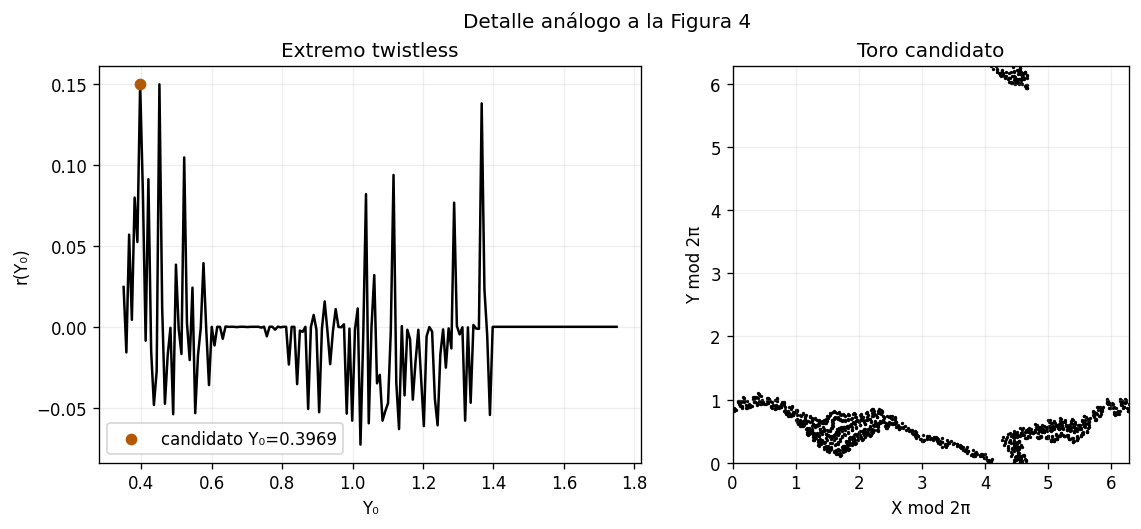

In [9]:
orbit_03, rotation_03 = rotation_results[(0.3, 0.14)]
candidate = np.argmax(rotation_03)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.3), constrained_layout=True)
axes[0].plot(y0, rotation_03, color='black')
axes[0].scatter(y0[candidate], rotation_03[candidate], color='#b35806', zorder=3,
                label=f'candidato Y₀={y0[candidate]:.4f}')
axes[0].set(xlabel='Y₀', ylabel='r(Y₀)', title='Extremo twistless')
axes[0].legend()
axes[1].scatter(np.mod(orbit_03[:, 0, candidate], TAU),
                np.mod(orbit_03[:, 1, candidate], TAU), s=1, color='black')
axes[1].set(xlabel='X mod 2π', ylabel='Y mod 2π', title='Toro candidato',
            xlim=(0, TAU), ylim=(0, TAU), aspect='equal')
fig.suptitle('Detalle análogo a la Figura 4')
plt.show()

## Figura 6: regularización para ρ grande

El artículo muestra una dinámica muy regular para A=0.7, ρ=1.5 y η=0.05.

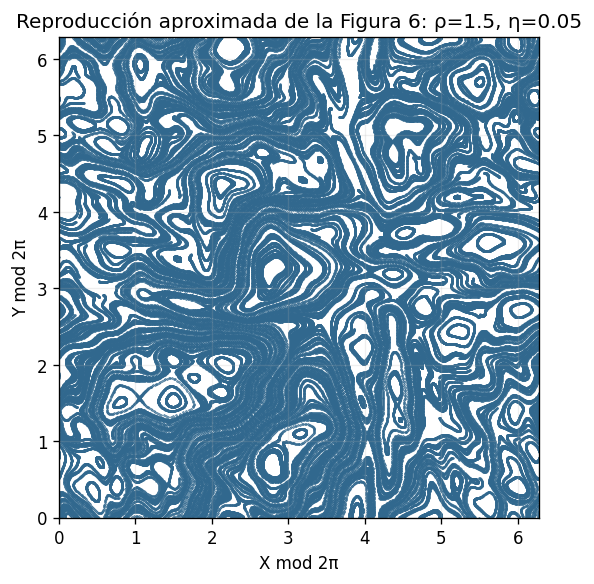

In [10]:
model_15 = build_effective_potential(1.5, 0.05)
positions_15, _ = rk4_stroboscopic(rhs_guiding_center, initial,
                                      P['periods'], P['dt_gc'], args=(model_15,))
plt.figure(figsize=(5.2, 5.2))
plt.scatter(np.mod(positions_15[:, 0], TAU), np.mod(positions_15[:, 1], TAU),
            s=0.2, color=COLORS['trapped'], rasterized=True)
plt.xlim(0, TAU); plt.ylim(0, TAU); plt.gca().set_aspect('equal')
plt.xlabel('X mod 2π'); plt.ylabel('Y mod 2π')
plt.title('Reproducción aproximada de la Figura 6: ρ=1.5, η=0.05')
plt.show()

## Figura 7: mapa del exponente b en el espacio (ρ,η)

Esta es la sección más costosa. Para cada par se integran trayectorias, se descartan las atrapadas y se ajusta MSD(t)≈(at)ᵇ. El perfil rápido busca recuperar cualitativamente la región superdifusiva para ρ≳0.2 y |η|≲0.2; una reproducción cuantitativa exige aumentar resolución, conjunto y duración.

Cambia RUN_SCAN a True en la celda de configuración para ejecutarla.

In [11]:
def transport_exponent_for_parameters(rho, eta, ntraj=12**2, periods=160, dt=0.08):
    model = build_effective_potential(rho, eta)
    positions, _ = rk4_stroboscopic(rhs_guiding_center, fixed_initial_conditions(ntraj),
                                      periods, dt, args=(model,))
    times, msd = time_ensemble_msd(positions, mobile_mask(positions), n_lags=45)
    return fit_transport_exponent(times, msd)[0]


if RUN_SCAN:
    rho_values = np.linspace(0, 0.7, 9) if PROFILE == 'QUICK' else np.linspace(0, 1.5, 31)
    eta_values = np.linspace(-0.2, 0.2, 9) if PROFILE == 'QUICK' else np.linspace(-0.25, 0.25, 41)
    exponent_map = np.empty((len(eta_values), len(rho_values)))
    for i, eta in enumerate(eta_values):
        for j, rho in enumerate(rho_values):
            exponent_map[i, j] = transport_exponent_for_parameters(rho, eta)
        print(f'fila {i+1}/{len(eta_values)} terminada')
    np.savez_compressed(PROJECT_ROOT / 'notebooks' / 'article_scan_cache.npz',
                        rho=rho_values, eta=eta_values, b=exponent_map)
elif (PROJECT_ROOT / 'notebooks' / 'article_scan_cache.npz').exists():
    cached = np.load(PROJECT_ROOT / 'notebooks' / 'article_scan_cache.npz')
    rho_values, eta_values, exponent_map = cached['rho'], cached['eta'], cached['b']
else:
    exponent_map = None
    print('Barrido omitido: activa RUN_SCAN=True.')

if exponent_map is not None:
    plt.figure(figsize=(7, 4.5))
    image = plt.pcolormesh(rho_values, eta_values, exponent_map, shading='auto',
                           cmap='OrRd', vmin=1, vmax=2)
    plt.colorbar(image, label='exponente b')
    plt.xlabel('ρ'); plt.ylabel('η'); plt.title('Reproducción aproximada de la Figura 7')
    plt.show()

Barrido omitido: activa RUN_SCAN=True.


## Figura 8: parámetros próximos a Tore Supra

Se repite el diagnóstico para A=0.7, ρ=0.3 y η=7×10⁻⁵. El artículo encuentra el caso dentro de la región superdifusiva.

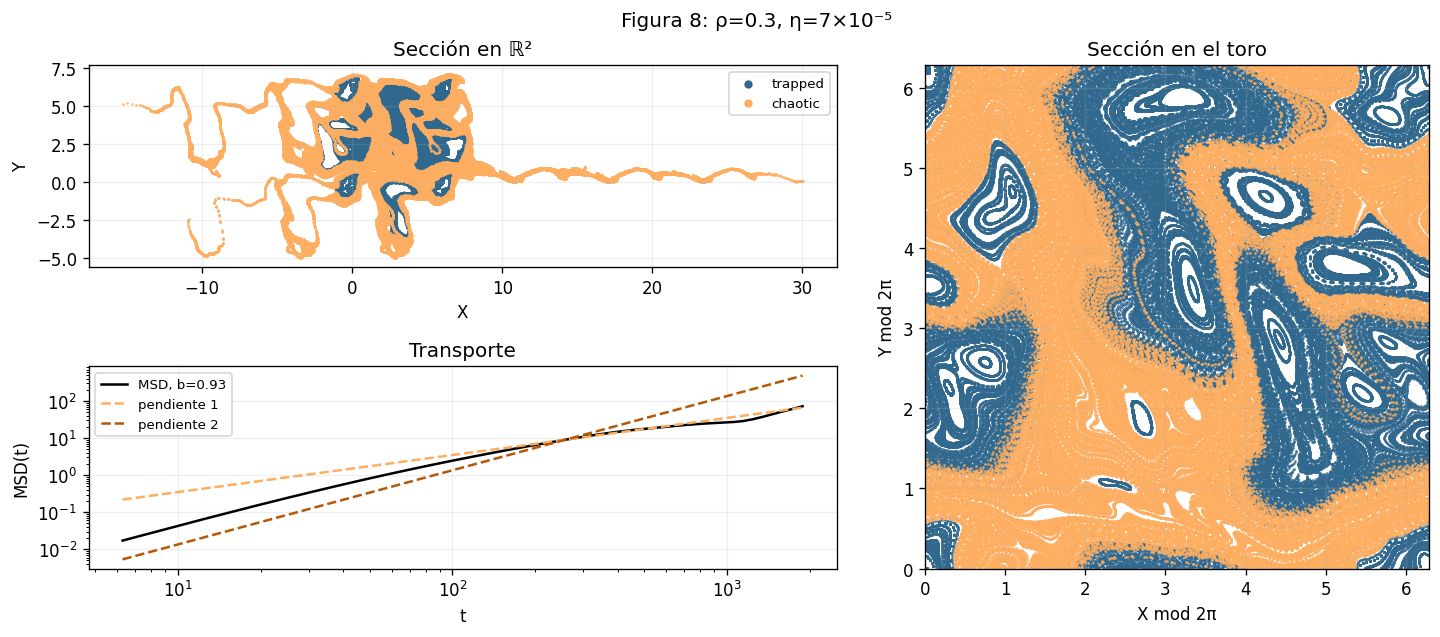

In [12]:
model_ts = build_effective_potential(0.3, 7e-5)
positions_ts, _ = rk4_stroboscopic(rhs_guiding_center, initial,
                                     P['periods'], P['dt_gc'], args=(model_ts,))
times_ts, msd_ts = time_ensemble_msd(positions_ts, mobile_mask(positions_ts))
b_ts, a_ts = fit_transport_exponent(times_ts, msd_ts)
case_ts = dict(positions=positions_ts, times=times_ts, msd=msd_ts,
               exponent=b_ts, scale=a_ts)
_ = plot_transport_triptych(case_ts, 'Figura 8: ρ=0.3, η=7×10⁻⁵')
plt.show()

## Figura 9: órbitas completas

Se integran ẋ=ρv/(2|η|) y v̇=−sgn(η)∇φ/ρ+(v×ẑ)/(2η), con velocidades iniciales unitarias y giroángulos uniformes. Después se reconstruyen los centros guía mediante las fórmulas publicadas. El paso recomendado es 0.005; incluso la versión reducida es costosa.

Cambia RUN_FULL_ORBITS a True para ejecutar esta sección.

In [13]:
def rhs_full_orbit(t, state, model):
    rho, eta = model.rho, model.eta
    x, y, vx, vy = state
    dphi_dx, dphi_dy = original_potential_gradient(model, x, y, t)
    return np.stack((rho * vx / (2*abs(eta)), rho * vy / (2*abs(eta)),
                     -np.sign(eta)*dphi_dx/rho + vy/(2*eta),
                     -np.sign(eta)*dphi_dy/rho - vx/(2*eta)))


def reconstruct_guiding_centers(full_orbits, rho):
    x, y, vx, vy = np.moveaxis(full_orbits, 1, 0)
    rho_v = rho * np.hypot(vx, vy)
    theta = np.pi + np.arctan2(vx, vy)
    return np.stack((x - rho_v*np.cos(theta), y + rho_v*np.sin(theta)), axis=1)


if RUN_FULL_ORBITS:
    fo_model = build_effective_potential(0.3, 0.14)
    n_fo = 16**2 if PROFILE == 'QUICK' else P['ntraj']
    xy0 = fixed_initial_conditions(n_fo)
    gyroangle = TAU * np.random.RandomState(SEED + 1).random(n_fo)
    fo_initial = np.vstack((xy0, np.cos(gyroangle), np.sin(gyroangle)))
    fo_periods = 120 if PROFILE == 'QUICK' else P['periods']
    fo_dt = 0.01 if PROFILE == 'QUICK' else 0.005
    full_orbits, actual_fo_dt = rk4_stroboscopic(
        rhs_full_orbit, fo_initial, fo_periods, fo_dt, args=(fo_model,))
    gc_from_fo = reconstruct_guiding_centers(full_orbits, fo_model.rho)
    times_fo, msd_fo = time_ensemble_msd(gc_from_fo, mobile_mask(gc_from_fo))
    b_fo, a_fo = fit_transport_exponent(times_fo, msd_fo)
    fo_case = dict(positions=gc_from_fo, times=times_fo, msd=msd_fo,
                   exponent=b_fo, scale=a_fo)
    _ = plot_transport_triptych(fo_case, f'Figura 9: centros guía reconstruidos, b={b_fo:.2f}')
    plt.show()
else:
    print('Órbitas completas omitidas: activa RUN_FULL_ORBITS=True.')

Órbitas completas omitidas: activa RUN_FULL_ORBITS=True.


## Lectura de los resultados y límites

La señal principal que debe sobrevivir al perfil reducido es el paso de una nube caótica con MSD aproximadamente lineal para (ρ,η)=(0,0) a capas largas y un MSD cercano a cuadrático para (0.3,0.14). Los extremos de r(Y₀) identifican los toros twistless que bloquean transporte transversal y favorecen transporte casi balístico en la dirección longitudinal.

Para acercarse a las cifras del artículo:

1. Selecciona PROFILE='ARTICLE'.
2. Ejecuta primero una sola pareja de parámetros y verifica convergencia al duplicar malla y reducir Δt.
3. Aumenta periodos y condiciones iniciales antes de interpretar b.
4. Activa RUN_SCAN y RUN_FULL_ORBITS por separado.
5. Compara el error y las estructuras al usar interpolación lineal periódica, como prescribe el Apéndice B.

Diferencia importante con classes.FourierPotential + Trajectory + System: esa clase aplica actualmente solo J₀[φ] a centros guía, por lo que η no altera su dinámica GC. Este notebook incluye expresamente el término de segundo orden requerido por el artículo.